In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from data_science.plots import plot_clusters, plot_elbow, plot_pca_scatter
from data_science.styles import apply_luna_style

In [4]:
apply_luna_style()

## Data


In [5]:
data = pd.read_csv(
    "./../../data/wine_quality_merged.csv",
)

## Prepare Data


In [6]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x1254F75A0

In [7]:
X = data.drop(columns=["type"])
y = data["type"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## PCA


In [10]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_2d.fit_transform(X_scaled)

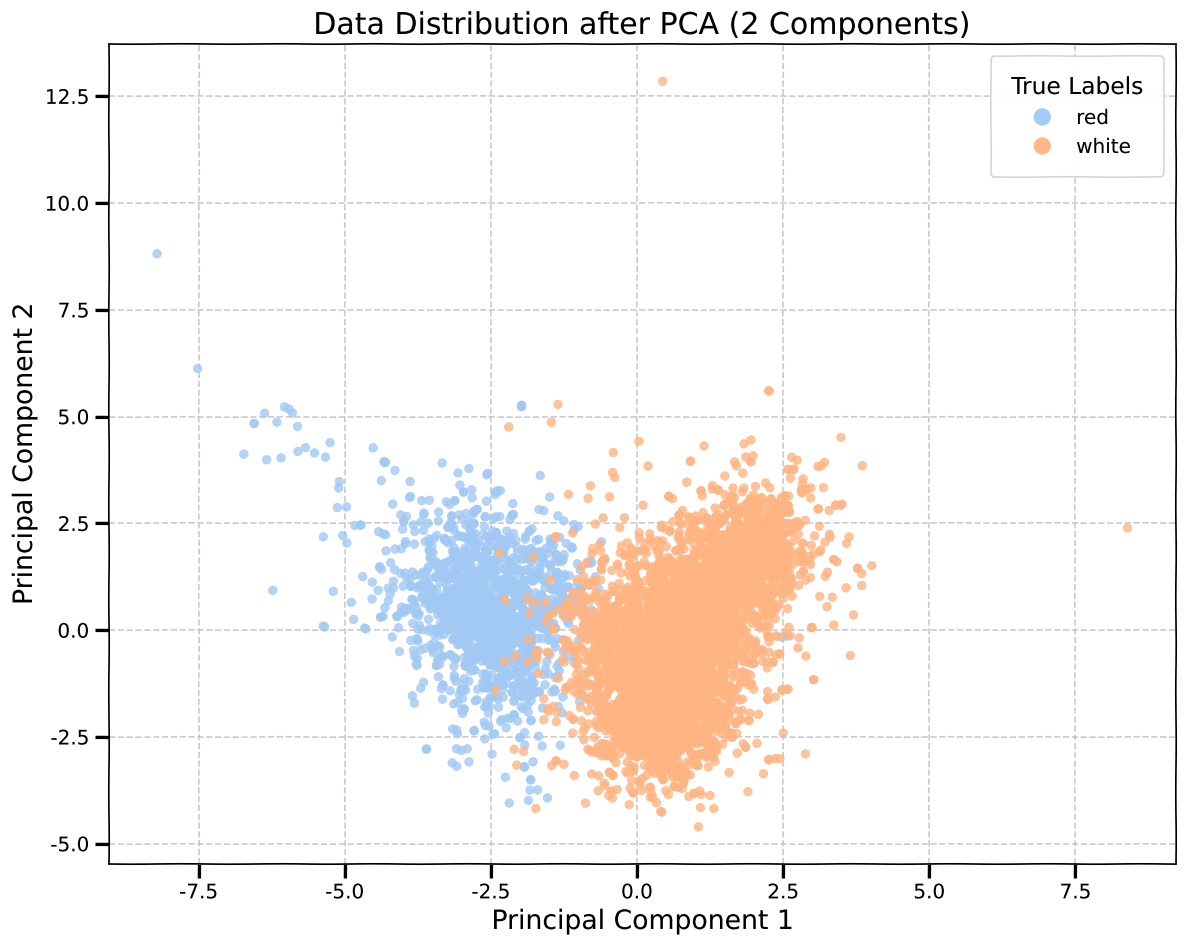

In [11]:
plot_pca_scatter(
    X_pca_2d,
    y,
    title='Data Distribution after PCA (2 Components)',
    palette='pastel',
)

## Kmeans


### Elbow Method


In [12]:
wcss = []
Ks = range(1, 16)
for k in Ks:
    kmeans = KMeans(
        n_init=10,
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    kmeans.fit(X_pca_2d)
    wcss.append(kmeans.inertia_)

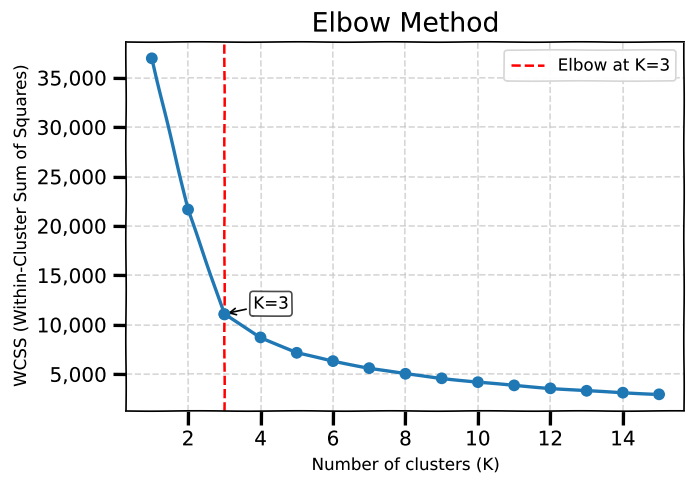

np.int64(3)

In [13]:
plot_elbow(Ks, wcss)

### KMeans (k=3)


In [14]:
kmeans_k3 = KMeans(
    n_clusters=3,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k3 = kmeans_k3.fit_predict(X_pca_2d)

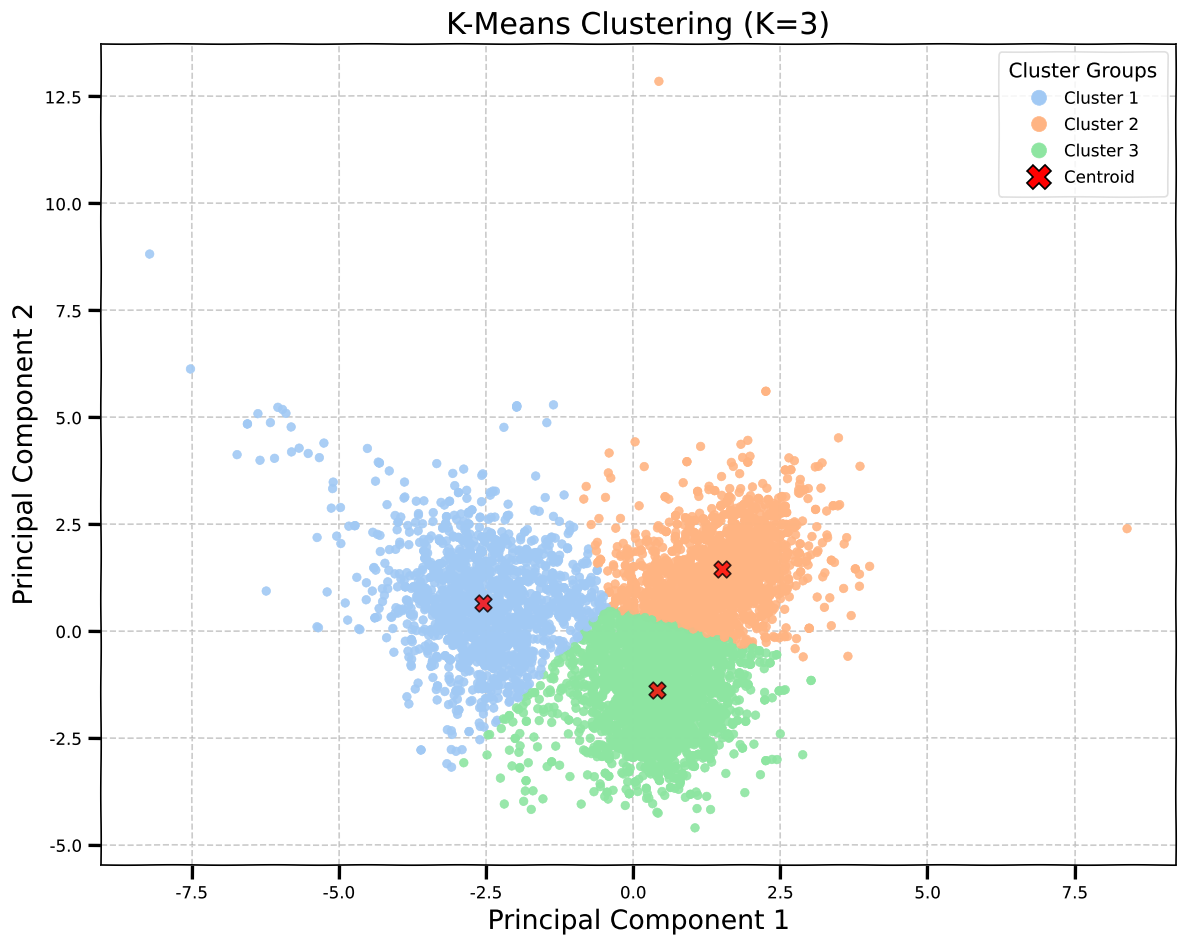

In [15]:
plot_clusters(
    km_labels_k3,
    X_pca_2d,
    title='K-Means Clustering (K=3)',
    palette='pastel',
)

### KMeans (k=2)


In [16]:
kmeans_k2 = KMeans(
    n_clusters=2,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k2 = kmeans_k2.fit_predict(X_pca_2d)

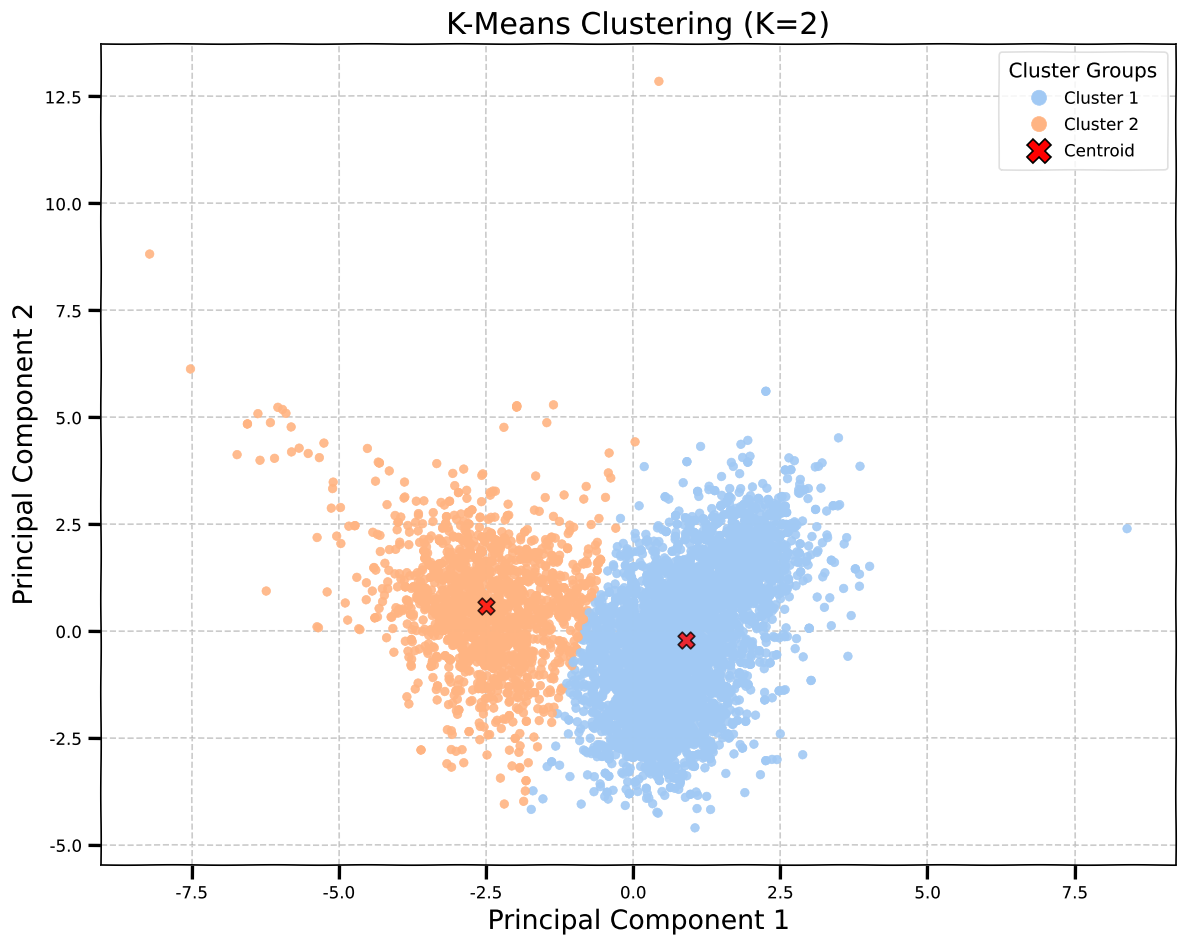

In [17]:
plot_clusters(
    km_labels_k2,
    X_pca_2d,
    title='K-Means Clustering (K=2)',
    palette='pastel',
)

### Evaluate KMeans Results


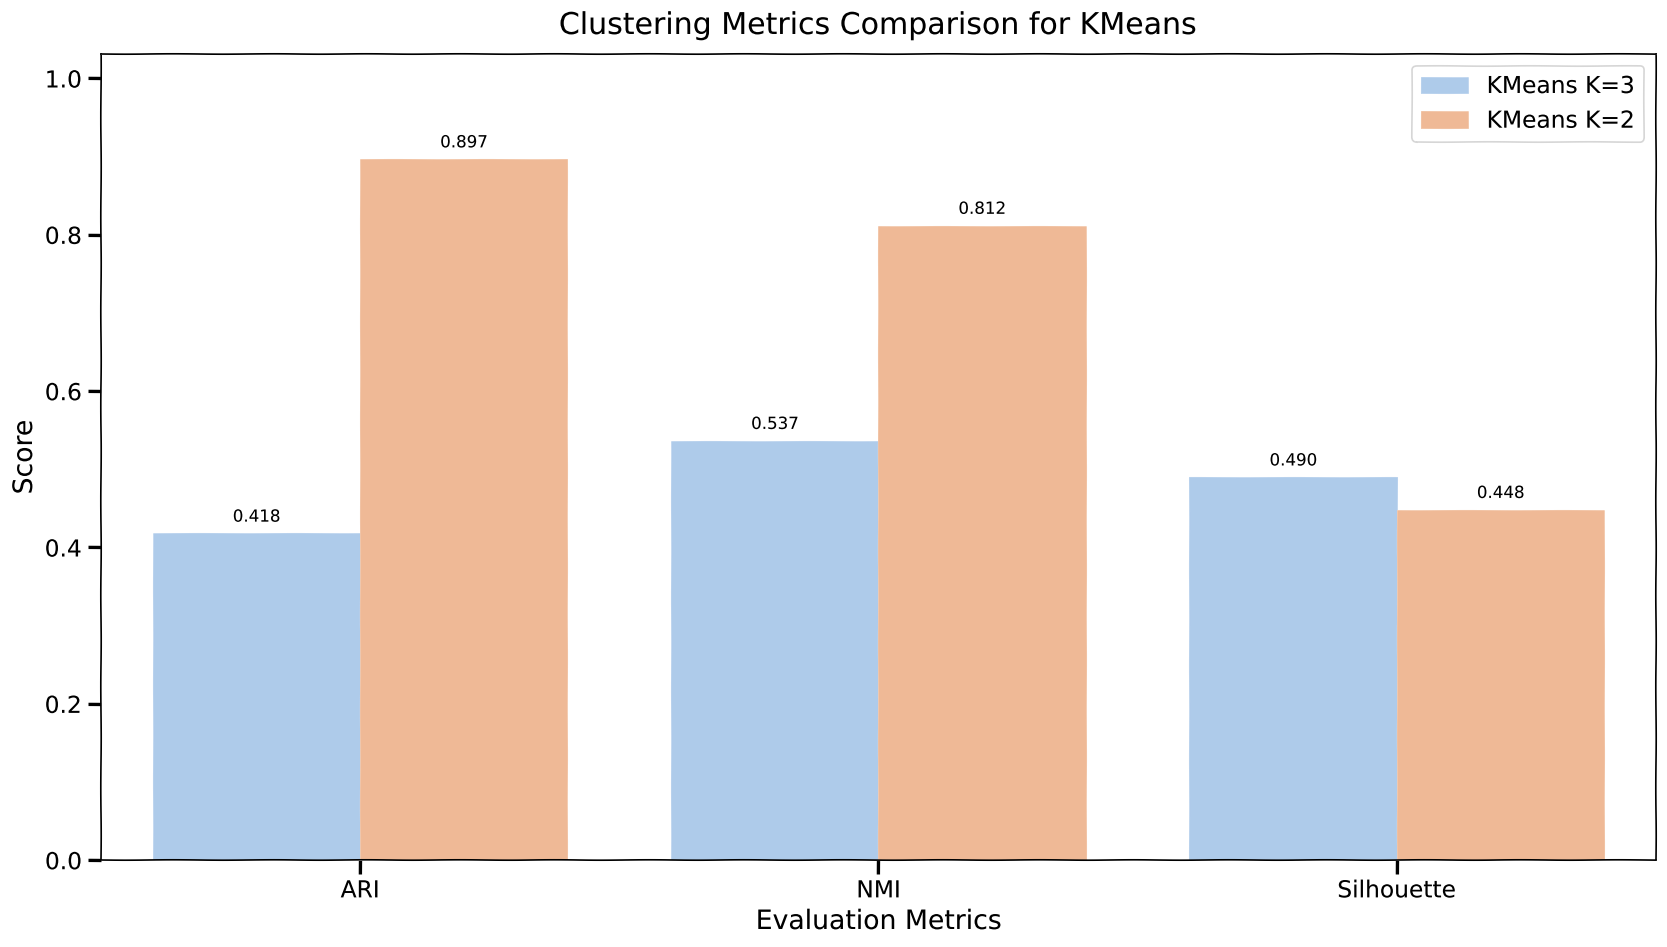

In [18]:
from data_science.tests import evaluate_clustering_performance, plot_clustering_metrics

_ = plot_clustering_metrics(
    results=[
        ('KMeans K=3', evaluate_clustering_performance(y, km_labels_k3, X_pca_2d)),
        ('KMeans K=2', evaluate_clustering_performance(y, km_labels_k2, X_pca_2d)),
    ],
    title='Clustering Metrics Comparison for KMeans',
    palette='pastel',
    metrics=[
        "adjusted_rand_score",
        "normalized_mutual_info",
        "silhouette"
    ]
)
